In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("./dataset/data.csv")
display(data.head(10))
print(data.shape)
print(data.isna().sum())

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,1,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,1,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,1,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,1,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,1,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


(39942, 5)
label      0
title      0
text       0
subject    0
date       0
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, train_size=0.2, random_state=42)

In [4]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


In [5]:
def clean_sentence(text):
    clean_punctuation = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    trim_spaces_text = re.sub(r"\s(?=\s)", "", clean_punctuation)
    return trim_spaces_text.lower()

# lowercase data and clean punctuation and spaces
def clean_data(data):
    return [clean_sentence(sentence) for sentence in data]

# tokenize data and clean stopwords
def filter_data(data):
    tokenized_data = [word_tokenize(sentence) for sentence in data]
    stop_words = set(stopwords.words('english'))
    return [[word for word in sentence if word not in stop_words] for sentence in tokenized_data]

corpus = filter_data(clean_data(data.text))
corpus[0:50]

[['washington',
  'reuters',
  'head',
  'conservative',
  'republican',
  'faction',
  'us',
  'congress',
  'voted',
  'month',
  'huge',
  'expansion',
  'national',
  'debt',
  'pay',
  'tax',
  'cuts',
  'called',
  '“',
  'fiscal',
  'conservative',
  '”',
  'sunday',
  'urged',
  'budget',
  'restraint',
  '2018',
  'keeping',
  'sharp',
  'pivot',
  'way',
  'among',
  'republicans',
  'us',
  'representative',
  'mark',
  'meadows',
  'speaking',
  'cbs',
  '’',
  '“',
  'face',
  'nation',
  '”',
  'drew',
  'hard',
  'line',
  'federal',
  'spending',
  'lawmakers',
  'bracing',
  'battle',
  'january',
  'return',
  'holidays',
  'wednesday',
  'lawmakers',
  'begin',
  'trying',
  'pass',
  'federal',
  'budget',
  'fight',
  'likely',
  'linked',
  'issues',
  'immigration',
  'policy',
  'even',
  'november',
  'congressional',
  'election',
  'campaigns',
  'approach',
  'republicans',
  'seek',
  'keep',
  'control',
  'congress',
  'president',
  'donald',
  'trump',


In [6]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_data(data):
    return [[lemmatizer.lemmatize(word) for word in sentence] for sentence in data]

lemmatized_corpus = lemmatize_data(corpus)
lemmatized_corpus[0:50]

[['washington',
  'reuters',
  'head',
  'conservative',
  'republican',
  'faction',
  'u',
  'congress',
  'voted',
  'month',
  'huge',
  'expansion',
  'national',
  'debt',
  'pay',
  'tax',
  'cut',
  'called',
  '“',
  'fiscal',
  'conservative',
  '”',
  'sunday',
  'urged',
  'budget',
  'restraint',
  '2018',
  'keeping',
  'sharp',
  'pivot',
  'way',
  'among',
  'republican',
  'u',
  'representative',
  'mark',
  'meadow',
  'speaking',
  'cbs',
  '’',
  '“',
  'face',
  'nation',
  '”',
  'drew',
  'hard',
  'line',
  'federal',
  'spending',
  'lawmaker',
  'bracing',
  'battle',
  'january',
  'return',
  'holiday',
  'wednesday',
  'lawmaker',
  'begin',
  'trying',
  'pas',
  'federal',
  'budget',
  'fight',
  'likely',
  'linked',
  'issue',
  'immigration',
  'policy',
  'even',
  'november',
  'congressional',
  'election',
  'campaign',
  'approach',
  'republican',
  'seek',
  'keep',
  'control',
  'congress',
  'president',
  'donald',
  'trump',
  'republica

In [7]:
# join data in sentences
def join_sentences(data):
    return [" ".join(sentence_words) for sentence_words in data]

In [8]:
def preprocess_data(data):
    return join_sentences(lemmatize_data(filter_data(clean_data(data))))

data_train['preprocessed_text'] = preprocess_data(data_train.text)
data_val['preprocessed_text'] = preprocess_data(data_val.text)

In [20]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import NaiveBayesClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
# BoW
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(data_train['preprocessed_text']).toarray()
bow_df = pd.DataFrame(bow_matrix, columns=bow_vectorizer.get_feature_names_out(), index=data_train['preprocessed_text'])
real_word_counts = bow_df[bow_df['label'] == 0].drop(columns='label').sum().sort_values(ascending=False)
spam_word_counts = bow_df[bow_df['label'] == 1].drop(columns='label').sum().sort_values(ascending=False)
print(real_word_counts.head(10))
print(spam_word_counts.head(10))

trump         23762
said          23525
state         10265
would         10043
president      9467
republican     7604
people         7444
one            6466
year           6039
new            5511
dtype: int64
trump        164
said         133
state        111
president     58
one           53
would         52
people        51
say           48
american      43
white         41
dtype: int64


In [11]:
# TF-IDF
count_vectorizer = CountVectorizer()
tfidf_transformer = TfidfTransformer()
term_freq_matrix = count_vectorizer.fit_transform(data_train['preprocessed_text'])
tf_idf_matrix = tfidf_transformer.fit_transform(term_freq_matrix)

tfidf_df = pd.DataFrame(tf_idf_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())
tfidf_df['label'] = data_train.label.values

real_word_counts = tfidf_df[tfidf_df['label'] == 0].drop(columns='label').sum().sort_values(ascending=False)
spam_word_counts = tfidf_df[tfidf_df['label'] == 1].drop(columns='label').sum().sort_values(ascending=False)
print(real_word_counts.head(10))
print(spam_word_counts.head(10))

trump        232.054566
clinton       83.461145
people        80.909006
obama         75.965602
president     74.308563
like          68.297606
hillary       68.071422
image         67.311517
one           66.799000
said          63.368269
dtype: float64
said          243.206382
trump         171.987939
state         117.416240
reuters       115.659133
republican     99.481426
would          96.539885
president      93.901945
house          83.626799
government     77.820788
washington     74.245121
dtype: float64


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(data_val['preprocessed_text'])

def show_results_data(models, labels):
    fig, axes = plt.subplots(4, 4, figsize=(12, 10))
    axes = axes.ravel()

    for i, (name, preds) in enumerate(models.items()):
        print(f"Model: {name}")
        print("--------------------")
        print(classification_report(labels, preds, target_names=['ham', 'spam'], digits=4))
        
        ConfusionMatrixDisplay.from_predictions(
            labels, preds,
            display_labels=['real', 'fake'],
            cmap='Blues',
            ax=axes[i],
            colorbar=False
        )
        axes[i].set_title(name)

    plt.tight_layout()
    plt.show()

6524     january 3 story corrected remove reference par...
30902    much healthy debate college campus instead lib...
36459    information spilling little little know hillar...
9801     washington reuters u republican presidential c...
25638    attention conservative men one youafter readin...
                               ...                        
6942     taipei reuters taiwan president tsai ingwen ex...
3391     detroitwashington reuters president donald tru...
2170     washingtonnew york reuters u president donald ...
22844    play right vladimir putin rule dictator donald...
35342    working people america basically supposed sit ...
Name: preprocessed_text, Length: 31954, dtype: object


In [13]:
# Bag of words + NaiveBayes
def document_features(text):
    words = word_tokenize(text.lower())
    return {word: True for word in words}

train_set = [(document_features(text), label) 
             for text, label in zip(data_train['preprocessed_text'], data_train['label'])]

val_set = [(document_features(text), label) 
           for text, label in zip(data_val['preprocessed_text'], data_val['label'])]

classifierNB = NaiveBayesClassifier.train(train_set)

val_features_only = [features for features, label in val_set]
nltk_nb_pred = [classifierNB.classify(feats) for feats in val_features_only]

In [ ]:
# BoW + Multinomial NaiveBayes
X_val_counts = count_vectorizer.transform(data_val['preprocessed_text'])
classifierMultNB = MultinomialNB()
classifierMultNB.fit(bow_matrix, data_train.label)

mult_nb_bow_pred = classifierMultNB.predict(X_val_counts)

In [15]:
# BoW + linear SVC
linear_SVC_BoW_classifier = LinearSVC()
linear_SVC_BoW_classifier.fit(bow_matrix, data_train['label'])

linear_SVC_BoW_pred = linear_SVC_BoW_classifier.predict(X_val_counts)

c:\Users\agcor\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
# BoW + Logistic regression
count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_count = count_vectorizer.transform(data_val['preprocessed_text'])

lr_BoW_classifier = LogisticRegression()
lr_BoW_classifier.fit(X_train_count, data_train['label'])

lr_BoW_pred = lr_BoW_classifier.predict(X_val_count)

In [29]:
# BoW bigrams + Logistic regression
bow_bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_train_bigram_matrix = bow_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bigram_count = bow_bigram_vectorizer.transform(data_val['preprocessed_text'])

lr_BoW_classifier = LogisticRegression()
lr_BoW_classifier.fit(X_train_bigram_matrix, data_train['label'])

lr_BoW_bigram_pred = lr_BoW_classifier.predict(X_val_bigram_count)

In [31]:
# BoW bigrams + Linear SVC
bow_bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_train_bigram_matrix = bow_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bigram_count = bow_bigram_vectorizer.transform(data_val['preprocessed_text'])

linear_SVC_BoW_classifier = LinearSVC()
linear_SVC_BoW_classifier.fit(X_train_bigram_matrix, data_train['label'])

linear_SVC_BoW_bigram_pred = linear_SVC_BoW_classifier.predict(X_val_bigram_count)

c:\Users\agcor\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
# BoW bigrams + Multinomial NaiveBayes
bow_bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_train_bigram_matrix = bow_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bigram_count = bow_bigram_vectorizer.transform(data_val['preprocessed_text'])

classifierMultNB = MultinomialNB()
classifierMultNB.fit(X_train_bigram_matrix, data_train.label)
mult_nb_BoW_bigram_pred = classifierMultNB.predict(X_val_bigram_count)

In [16]:
# TF-IDF + NaiveBayes
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(data_train['preprocessed_text'])
feature_names = tfidf_vectorizer.get_feature_names_out()

def document_features_tfidf(text, vectorizer, feature_names, n_bins=3):
    vec = vectorizer.transform([text]).toarray()[0]
    features = {}
    for word, score in zip(feature_names, vec):
        if score > 0:
            bin_label = 'low' if score < 0.2 else ('medium' if score < 0.5 else 'high')
            features[word] = bin_label
    return features

train_set = [(document_features_tfidf(text, tfidf_vectorizer, feature_names), label) 
             for text, label in zip(data_train['preprocessed_text'], data_train['label'])]

val_set = [(document_features_tfidf(text, tfidf_vectorizer, feature_names), label) 
           for text, label in zip(data_val['preprocessed_text'], data_val['label'])]

classifier = NaiveBayesClassifier.train(train_set)

val_features_only = [features for features, label in val_set]
nltk_nb_tfidf_pred = [classifier.classify(feats) for feats in val_features_only]

In [17]:
# TF-IDF + Multinomial NaiveBayes
count_vectorizer = CountVectorizer()
term_freq_matrix = count_vectorizer.fit_transform(data_train['preprocessed_text'])

tfidf_transformer = TfidfTransformer()
tf_idf_matrix = tfidf_transformer.fit_transform(term_freq_matrix)
X_val_tfidf = tfidf_transformer.transform(X_val_counts)

classifierMultNB = MultinomialNB()
classifierMultNB.fit(tf_idf_matrix, data_train.label)

mult_nb_tfidf_pred = classifierMultNB.predict(X_val_tfidf)

In [24]:
# TF-IDF + Linear SVC
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.95, min_df=2, sublinear_tf=True)
linear_SVC_TFIDF_classifier = LinearSVC()

X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
linear_SVC_TFIDF_classifier.fit(X_train_tfidf, data_train['label'])

X_test_tfidf = tfidf_vectorizer.transform(data_val['preprocessed_text'])
linear_SVC_TFIDF_pred = linear_SVC_TFIDF_classifier.predict(X_test_tfidf)

In [ ]:
# TF-IDF + Logistic regression
tfidf_vectorizer = TfidfVectorizer(sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf = tfidf_vectorizer.transform(data_val['preprocessed_text'])

lr_TFIDF_classifier = LogisticRegression()
lr_TFIDF_classifier.fit(X_train_tfidf, data_train['label'])

lr_TFIDF_pred = lr_TFIDF_classifier.predict(X_val_tfidf)

In [37]:
# TF-IDF bigram + MultinomialNB
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf_bigram = tfidf_bigram_vectorizer.transform(data_val['preprocessed_text'])

classifierMultNB = MultinomialNB()
classifierMultNB.fit(X_train_tfidf_bigram, data_train.label)

mult_nb_tfidf_bigram_pred = classifierMultNB.predict(X_val_tfidf_bigram)

In [41]:
# TF-IDF Bigram + Linear SVC
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf_bigram = tfidf_bigram_vectorizer.transform(data_val['preprocessed_text'])

linear_SVC_TFIDF_classifier = LinearSVC()
linear_SVC_TFIDF_classifier.fit(X_train_tfidf_bigram, data_train['label'])
linear_SVC_TFIDF_bigram_pred = linear_SVC_TFIDF_classifier.predict(X_val_tfidf_bigram)

In [40]:
# TF-IDF bigram + LogisticRegression
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf_bigram = tfidf_bigram_vectorizer.transform(data_val['preprocessed_text'])

lr_TFIDF_classifier = LogisticRegression()
lr_TFIDF_classifier.fit(X_train_tfidf_bigram, data_train['label'])

lr_TFIDF_bigram_pred = lr_TFIDF_classifier.predict(X_val_tfidf_bigram)

In [45]:
models_predictions = {
    "BoW + NaiveBayes": nltk_nb_pred,
    "BoW + MultinomialNB": mult_nb_bow_pred,
    "BoW + LinearSVC": linear_SVC_BoW_pred,
    "BoW + LogisticRegression": lr_BoW_pred,
    "BoW bigram + LogisticRegression": lr_BoW_bigram_pred,
    "Bow bigram + LinearSVC": linear_SVC_BoW_bigram_pred,
    "Bow bigram + MultinomialNB": mult_nb_BoW_bigram_pred,
    "TF-IDF + NaiveBayes": nltk_nb_tfidf_pred,
    "TF-IDF + MultinomialNB": mult_nb_tfidf_pred,
    "TF-IDF + LinearSVC": linear_SVC_TFIDF_pred,
    "TF-IDF + LogisticRegression": lr_TFIDF_pred,
    "TF-IDF bigram + MultinomialNB": mult_nb_tfidf_bigram_pred,
    "TF-IDF bigram + LinearSVC": linear_SVC_TFIDF_bigram_pred,
    "TF-IDF bigram + LogisticRegression": lr_TFIDF_bigram_pred
}

In [46]:
from sklearn.metrics import accuracy_score

def show_most_accuracy(models, labels):
    accuracies = {name: accuracy_score(labels, preds) for name, preds in models.items()}
    print(pd.Series(accuracies).sort_values(ascending=False))

show_most_accuracy(models_predictions, data_val.label)

BoW + LinearSVC                       0.992208
BoW + LogisticRegression              0.991613
TF-IDF + LinearSVC                    0.989172
TF-IDF + LogisticRegression           0.979001
TF-IDF bigram + LinearSVC             0.974901
TF-IDF bigram + LogisticRegression    0.965576
BoW bigram + LogisticRegression       0.960287
Bow bigram + LinearSVC                0.946548
BoW + NaiveBayes                      0.938881
Bow bigram + MultinomialNB            0.931808
TF-IDF + NaiveBayes                   0.930744
BoW + MultinomialNB                   0.926457
TF-IDF bigram + MultinomialNB         0.913469
TF-IDF + MultinomialNB                0.907085
dtype: float64


Model: BoW + NaiveBayes
--------------------
              precision    recall  f1-score   support

         ham     0.9937    0.8834    0.9353     15982
        spam     0.8950    0.9944    0.9421     15972

    accuracy                         0.9389     31954
   macro avg     0.9444    0.9389    0.9387     31954
weighted avg     0.9444    0.9389    0.9387     31954

Model: BoW + MultinomialNB
--------------------
              precision    recall  f1-score   support

         ham     0.9601    0.8899    0.9237     15982
        spam     0.8974    0.9630    0.9290     15972

    accuracy                         0.9265     31954
   macro avg     0.9287    0.9265    0.9264     31954
weighted avg     0.9287    0.9265    0.9264     31954

Model: BoW + LinearSVC
--------------------
              precision    recall  f1-score   support

         ham     0.9948    0.9896    0.9922     15982
        spam     0.9897    0.9948    0.9922     15972

    accuracy                         0.9922  

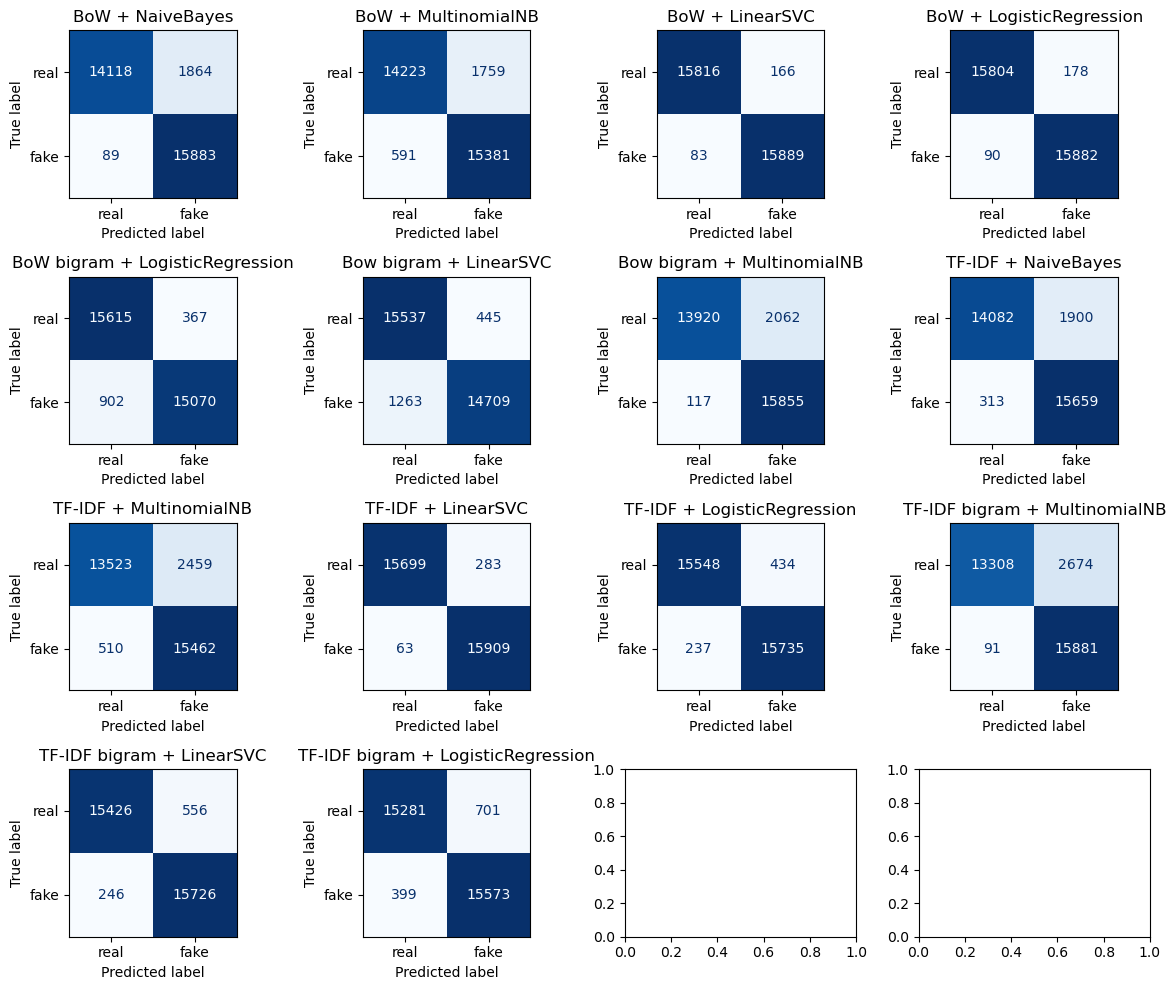

In [47]:
show_results_data(models_predictions, data_val.label)